## Hybrid E-Commerce Recommendation System

In [26]:
# Import Required Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Text processing
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# Similarity calculation
from sklearn.metrics.pairwise import cosine_similarity

# Evaluation metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Collaborative Filtering (Surprise Library)
from surprise import Dataset
from surprise import Reader
from surprise import KNNBasic
from surprise import KNNBaseline
from surprise import SVD

from surprise.model_selection import train_test_split as surprise_train_test_split

from surprise import accuracy

## Load Both Datasets

In [29]:
# File paths
PRODUCT_DATA = "D:\\DeskTop D\\Recommendation System\\data\\clean_amazon_products.csv"
RATINGS_DATA = "D:\\DeskTop D\\Recommendation System\\data\\amazon_ratings_electronics.csv"

# Load cleaned product dataset
products_df = pd.read_csv(PRODUCT_DATA)

# Load ratings dataset
ratings_df = pd.read_csv(
    RATINGS_DATA,
    names=["user_id", "asin", "rating", "timestamp"]
)

print("\nProduct Dataset Shape :", products_df.shape)
print("Ratings Dataset Shape :", ratings_df.shape)


Product Dataset Shape : (100000, 12)
Ratings Dataset Shape : (7824482, 4)


In [30]:
# Display first five rows of product dataset

print("First Five Rows of Product Dataset")

products_df.head()

First Five Rows of Product Dataset


,asin,title,imgUrl,category_name,price,listPrice,stars,reviews,isBestSeller,popularity_score,discount_percent,combined_text
0,B00870XPOI,White Cowhide Sporran,https://m.media-amazon.com/images/I/61EKgDigOG...,Men's Clothing,16.47,24.95,4.2,0,False,0.42,33.987976,White Cowhide Sporran Men's Clothing
1,B000PT18OS,Power Supply 203W AC Adapter XBOX 360 Compatib...,https://m.media-amazon.com/images/I/71E-XR7+Gi...,"Xbox 360 Games, Consoles & Accessories",59.41,0.00,4.3,0,False,0.43,0.000000,Power Supply 203W AC Adapter XBOX 360 Compatib...
2,B000B6MLPU,Microsoft Xbox 360 Component HD AV Cable,https://m.media-amazon.com/images/I/51nlGL+wM1...,"Xbox 360 Games, Consoles & Accessories",9.99,12.95,4.3,0,False,0.43,22.857143,Microsoft Xbox 360 Component HD AV Cable Xbox ...
3,B00ICOP4DY,Fosmon 2X Replacement Dongle USB Breakaway Cab...,https://m.media-amazon.com/images/I/61IPAOMMBU...,"Xbox 360 Games, Consoles & Accessories",7.99,0.00,4.6,0,False,0.46,0.000000,Fosmon 2X Replacement Dongle USB Breakaway Cab...
4,B002BSH9JY,Halo Reach,https://m.media-amazon.com/images/I/710pquWbf5...,"Xbox 360 Games, Consoles & Accessories",42.70,0.00,4.3,0,False,0.43,0.000000,"Halo Reach Xbox 360 Games, Consoles & Accessories"


In [31]:
# Display first five rows of ratings dataset

print("First Five Rows of Ratings Dataset")

ratings_df.head()

First Five Rows of Ratings Dataset


,user_id,asin,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


## Dataset Overview

In [32]:
# Product Dataset Information

products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   asin              100000 non-null  str    
 1   title             100000 non-null  str    
 2   imgUrl            100000 non-null  str    
 3   category_name     100000 non-null  str    
 4   price             100000 non-null  float64
 5   listPrice         100000 non-null  float64
 6   stars             100000 non-null  float64
 7   reviews           100000 non-null  int64  
 8   isBestSeller      100000 non-null  bool   
 9   popularity_score  100000 non-null  float64
 10  discount_percent  100000 non-null  float64
 11  combined_text     100000 non-null  str    
dtypes: bool(1), float64(5), int64(1), str(5)
memory usage: 42.8 MB


In [34]:
# Ratings Dataset Information
ratings_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   user_id    str    
 1   asin       str    
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 415.9 MB


In [35]:
# Check Missing Values

print("\nProduct Dataset")
print(products_df.isnull().sum())

print("\nRatings Dataset")
print(ratings_df.isnull().sum())


Product Dataset
asin                0
title               0
imgUrl              0
category_name       0
price               0
listPrice           0
stars               0
reviews             0
isBestSeller        0
popularity_score    0
discount_percent    0
combined_text       0
dtype: int64

Ratings Dataset
user_id      0
asin         0
rating       0
timestamp    0
dtype: int64


In [36]:
# Check Duplicate Values

print("Duplicate Products :", products_df.duplicated().sum())

print("Duplicate Ratings :", ratings_df.duplicated().sum())

Duplicate Products : 0
Duplicate Ratings : 0


In [37]:
products_df.describe()

,price,listPrice,stars,reviews,popularity_score,discount_percent
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,33.381304,15.863016,4.535775,2331.691340,0.665515,7.961981
std,58.171688,45.239767,0.205454,6104.373931,0.058478,13.593490
min,0.680000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.980000,0.000000,4.400000,396.000000,0.640623,0.000000
50%,18.990000,0.000000,4.600000,845.000000,0.663253,0.000000
75%,31.570000,16.490000,4.700000,2064.000000,0.693420,12.515645
max,2545.000000,999.990000,5.000000,346563.000000,0.943563,87.247875


In [38]:
ratings_df.describe()

,rating,timestamp
count,7.824482e+06,7.824482e+06
mean,4.012337e+00,1.338178e+09
std,1.380910e+00,6.900426e+07
min,1.000000e+00,9.127296e+08
25%,3.000000e+00,1.315354e+09
50%,5.000000e+00,1.361059e+09
75%,5.000000e+00,1.386115e+09
max,5.000000e+00,1.406074e+09


## Prepare Ratings Dataset

In [39]:
# Filter Ratings Dataset

# Number of ratings before filtering
original_ratings = len(ratings_df)

# Number of unique products before filtering
original_products = ratings_df["asin"].nunique()

# Keep only products that exist in cleaned product dataset
filtered_ratings_df = ratings_df[
    ratings_df["asin"].isin(products_df["asin"])
].copy()

In [40]:
# Dataset Summary After Filtering


filtered_summary = pd.DataFrame({

    "Metric":[
        "Total Ratings",
        "Unique Users",
        "Unique Products"
    ],

    "Value":[
        len(filtered_ratings_df),
        filtered_ratings_df["user_id"].nunique(),
        filtered_ratings_df["asin"].nunique()
    ]

})

filtered_summary

,Metric,Value
0,Total Ratings,374625
1,Unique Users,329953
2,Unique Products,3721


In [41]:
# Compare Before vs After Filtering

comparison = pd.DataFrame({

    "Before Filtering":[
        original_ratings,
        original_products
    ],

    "After Filtering":[
        len(filtered_ratings_df),
        filtered_ratings_df["asin"].nunique()
    ]

},

index=[
    "Total Ratings",
    "Unique Products"
])

comparison

,Before Filtering,After Filtering
Total Ratings,7824482,374625
Unique Products,476002,3721


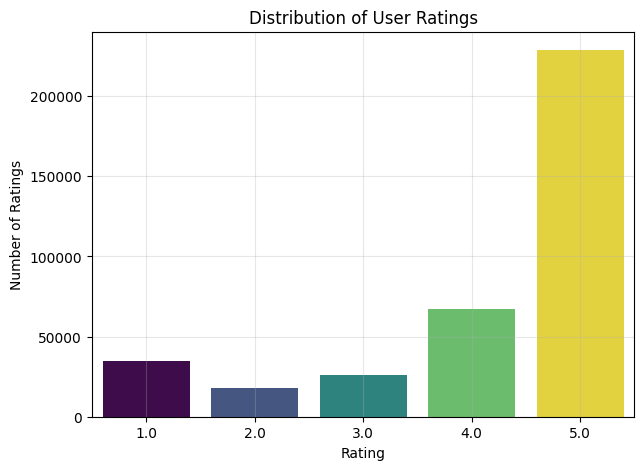

In [42]:
# Rating Distribution

plt.figure(figsize=(7,5))

sns.countplot(
    data=filtered_ratings_df,
    x="rating",
    hue="rating",
    palette="viridis",
    legend=False
)

plt.title("Distribution of User Ratings")

plt.xlabel("Rating")

plt.ylabel("Number of Ratings")

plt.grid(alpha=0.3)

plt.show()

In [43]:
# Top Rated Products

top_products = (

    filtered_ratings_df["asin"]

    .value_counts()

    .head(10)

)

top_products

asin
B004QK7HI8    7060
B005HMKKH4    6134
B007IV7KRU    4211
B005DKZTMG    4161
B004XC6GJ0    4018
B0043T7FXE    3373
B00A3YN0Z0    3292
B004T9RR6I    3182
B009OBCAW2    2786
B002SZEOLG    2666
Name: count, dtype: int64

## Content-Based Recommendation Model (TF-IDF)

In [44]:
# Display first few combined text values

products_df["combined_text"].head()

0                 White Cowhide Sporran Men's Clothing
1    Power Supply 203W AC Adapter XBOX 360 Compatib...
2    Microsoft Xbox 360 Component HD AV Cable Xbox ...
3    Fosmon 2X Replacement Dongle USB Breakaway Cab...
4    Halo Reach Xbox 360 Games, Consoles & Accessories
Name: combined_text, dtype: str

In [45]:
# Create TF-IDF object

tfidf = TfidfVectorizer(
    stop_words="english"
)

# Convert text into TF-IDF vectors

tfidf_matrix = tfidf.fit_transform(
    products_df["combined_text"]
)

print("TF-IDF Matrix Shape :", tfidf_matrix.shape)

TF-IDF Matrix Shape : (100000, 74823)


In [46]:
# Display first 20 important words

feature_names = tfidf.get_feature_names_out()

feature_names[:20]

array(['00', '000', '0000', '00001', '000013', '00005', '0001',
       '00010019000000', '000123', '000130', '00014', '000142', '00015',
       '00016', '00018', '00019', '0002', '00022', '000256', '00030'],
      dtype=object)

In [52]:
# Calculate Cosine Similarity

# Calculate Cosine Similarity for a small sample only
sample_size = 5
cosine_sim = cosine_similarity(
    tfidf_matrix[:sample_size],
)

print("Cosine Similarity Matrix Shape :", cosine_sim.shape)

Cosine Similarity Matrix Shape : (5, 5)


In [53]:
# Display similarity between first five products

similarity_sample = pd.DataFrame(
    cosine_sim[:5, :5]
)

similarity_sample

,0,1,2,3,4
0,1.0,0.000000,0.000000,0.000000,0.000000
1,0.0,1.000000,0.469852,0.388767,0.401644
2,0.0,0.469852,1.000000,0.474424,0.490137
3,0.0,0.388767,0.474424,1.000000,0.405552
4,0.0,0.401644,0.490137,0.405552,1.000000


In [54]:
# Map each product title to its index
product_index = pd.Series(
    products_df.index,
    index=products_df["title"]
).drop_duplicates()

print("Total Products Indexed :", len(product_index))

Total Products Indexed : 100000


## TF-IDF Recommendation Function

In [56]:
def recommend_tfidf(product_name, top_n=10):
    # Step 1 : Search product using keyword
    matching_products = products_df[
        products_df["title"].str.contains(
            product_name,
            case=False,
            na=False
        )
    ]

    # If no product is found
    if matching_products.empty:
        print(f'No product found containing "{product_name}".')
        return None
    
    # Step 2 : Select the first matched product

    selected_product = matching_products.iloc[0]["title"]

    # Step 3 : Get product index

    product_idx = product_index[selected_product]


    # Step 4 : Calculate cosine similarity

    similarity_scores = cosine_similarity(
        tfidf_matrix[product_idx],
        tfidf_matrix
    ).flatten()

    # Step 5 : Create similarity dataframe

    similarity_df = pd.DataFrame({

        "Product Index": products_df.index,

        "Similarity Score": similarity_scores

    })

    # Step 6 : Remove queried product

    similarity_df = similarity_df[
        similarity_df["Product Index"] != product_idx
    ]

    # Step 7 : Sort by similarity

    similarity_df = similarity_df.sort_values(

        by="Similarity Score",

        ascending=False

    )

    # Step 8 : Select Top-N products

    similarity_df = similarity_df.head(top_n)

    # Step 9 : Fetch product information

    recommendations = products_df.loc[
        similarity_df["Product Index"],
        [
            "title",
            "category_name",
            "price",
            "stars",
            "popularity_score"
        ]
    ].copy()

    # Add similarity score
    recommendations["Similarity Score"] = similarity_df[
        "Similarity Score"
    ].values

    # Reset index
    recommendations.reset_index(drop=True, inplace=True)

    return recommendations

In [57]:
# Display a few product titles
products_df["title"].sample(10, random_state=42)

75721    Floral Side Upcycled Canvas & Cowhide Leather ...
80184    J MAC BOTANICALS Organic Fractionated Coconut ...
19864    wet n wild Megalast Liquid Catsuit Lipstick, G...
76699                                     L.A. Noire (PS4)
92991    Wiha 32926 6.3-Inch Insulated Industrial Long ...
76434    Handbags for Women Canvas Fashion Large Capaci...
84004    YGJT 4 in 1 Tricycle for Toddlers Age 2-5, Fol...
80917                                 Womens Watch 2000960
60767                         Tulip One-Step Dye Kits- Red
50074    Girls' 2T-14 Casual Sundress Summer Autumn Clo...
Name: title, dtype: str

In [58]:
recommend_tfidf("canon")

,title,category_name,price,stars,popularity_score,Similarity Score
0,LP-E6 Battery for Canon LP-E6N LPE6 Promaster ...,Camera & Photo,14.99,4.6,0.460000,0.996996
1,"Wasabi Power LP-E6, LP-E6N Battery (2-Pack) an...",Camera & Photo,30.99,4.5,0.450000,0.619515
2,"BM Premium 2 LP-E6N Batteries for Canon EOS R,...",Camera & Photo,23.99,4.6,0.460000,0.322646
3,Canon LC-E6 Battery Charger for Canon EOS 5D M...,Accessories & Supplies,59.95,4.8,0.480000,0.301863
4,HQRP Battery Compatible with GolfBuddy LP-A10-...,GPS & Navigation,14.95,4.0,0.400000,0.282684
5,"Fotasy Cannon FD Lens to EOS EF Adapter, FD EF...",Camera & Photo,25.95,4.4,0.440000,0.222389
6,Vinyl Record Cleaning Brush Kit - Premium LP C...,Televisions & Video Products,11.99,4.7,0.643143,0.202864
7,LP E10 Battery for Canon Eos Rebel T6 T7 T5 T1...,Camera & Photo,9.99,4.6,0.460000,0.198025
8,BM Premium 2-Pack of LP-E8 Batteries and Batte...,Camera & Photo,20.99,4.7,0.470000,0.181697
9,Move Over Black Metal Novelty License Plate Ta...,Automotive Exterior Accessories,7.50,4.8,0.689578,0.180351


## Evaluate TF-IDF Content-Based Model

The TF-IDF model has no rating ground truth to compare against, so it is evaluated using **Category Precision@10** — the fraction of the top-10 recommended products that belong to the same category as the queried product — along with the **average similarity score** of those recommendations.

In [59]:
# Evaluate TF-IDF using Category Precision@10

np.random.seed(42)

# Randomly sample query products for evaluation
sample_indices = np.random.choice(products_df.index, size=200, replace=False)

top_n = 10
category_values = products_df["category_name"].values

precision_scores = []
avg_similarity_scores = []

for idx in sample_indices:

    # Similarity of the query product with every product
    similarity_scores = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten()

    similarity_df = pd.DataFrame({
        "Product Index": products_df.index,
        "Similarity Score": similarity_scores
    })

    # Remove the queried product itself
    similarity_df = similarity_df[similarity_df["Product Index"] != idx]

    # Select Top-N recommendations
    similarity_df = similarity_df.sort_values(
        by="Similarity Score",
        ascending=False
    ).head(top_n)

    # Check how many recommendations share the query's category
    recommended_categories = category_values[similarity_df["Product Index"].values]
    query_category = category_values[idx]

    match_count = (recommended_categories == query_category).sum()

    precision_scores.append(match_count / top_n)
    avg_similarity_scores.append(similarity_df["Similarity Score"].mean())

tfidf_category_precision = np.mean(precision_scores)
tfidf_avg_similarity = np.mean(avg_similarity_scores)

print(f"TF-IDF Category Precision@{top_n} : {tfidf_category_precision:.4f}")
print(f"TF-IDF Average Similarity Score   : {tfidf_avg_similarity:.4f}")

TF-IDF Category Precision@10 : 0.8975
TF-IDF Average Similarity Score   : 0.5281


In [60]:
tfidf_results = pd.DataFrame({

    "Metric": [
        f"Category Precision@{top_n}",
        "Average Similarity Score"
    ],

    "Value": [
        round(tfidf_category_precision, 4),
        round(tfidf_avg_similarity, 4)
    ]

})

tfidf_results

,Metric,Value
0,Category Precision@10,0.8975
1,Average Similarity Score,0.5281


## Build Collaborative Filtering Model KNN

In [61]:

# Keep only required columns
cf_data = filtered_ratings_df[
    ["user_id", "asin", "rating"]
].copy()

# Display first few rows
cf_data.head()

,user_id,asin,rating
4027,A1OICSUOT1PMJS,6575464564,5.0
4028,A37535FN4C9LB4,6575464564,5.0
7408,A1P6RQKZ880ZQD,B000001OKK,4.0
7409,A2S36TJIVV5XIU,B000001OKK,4.0
7410,A20BN510CTWZSJ,B000001OKK,5.0


In [62]:
# Rating scale in Amazon dataset
reader = Reader(rating_scale=(1, 5))

# Convert DataFrame into Surprise Dataset
surprise_data = Dataset.load_from_df(
    cf_data,
    reader
)

In [63]:
# Split into training and testing datasets
trainset, testset = surprise_train_test_split(
    surprise_data,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", trainset.n_ratings)
print("Testing Samples :", len(testset))

Training Samples : 299700
Testing Samples : 74925


In [ ]:
# Configure Item-Based KNN

similarity_options = {

    "name": "pearson_baseline",

    "user_based": False

}

# Create KNN model
knn_model = KNNBaseline(
    sim_options=similarity_options
)

In [65]:
# Train KNN Model

knn_model.fit(trainset)

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.


In [66]:
# Predict ratings for testing dataset
knn_predictions = knn_model.test(testset)

print("Total Predictions :", len(knn_predictions))

Total Predictions : 74925


In [67]:
# Display Sample Predictions

prediction_df = pd.DataFrame({

    "User ID": [pred.uid for pred in knn_predictions[:10]],

    "Product ASIN": [pred.iid for pred in knn_predictions[:10]],

    "Actual Rating": [pred.r_ui for pred in knn_predictions[:10]],

    "Predicted Rating": [
        round(pred.est,2)
        for pred in knn_predictions[:10]
    ]

})

prediction_df

,User ID,Product ASIN,Actual Rating,Predicted Rating
0,A2DJ9KR0Q82N0M,B002SZEOLG,5.0,4.11
1,A3KOZGS2PRM3Y8,B005HP3OB0,4.0,4.27
2,A1SUXM5083SKA3,B00005OT5X,4.0,4.15
3,AHZ0E8TFKMG9L,B004XC6GJ0,5.0,4.50
4,A1UJ66DZ3PZOP4,B001CIREXA,5.0,4.51
5,A2FPOOQFDQSB6T,B000Z7AKGC,4.0,3.56
6,A2ITI4JRVAUNA,B0000A989Y,3.0,3.57
7,A2TKE0ZDKUB5K2,B007IV7KRU,4.0,4.58
8,A253OSX4AC1J7U,B0045TYDNC,4.0,5.00
9,A2RIJZQLNBGXNO,B004T9RR6I,1.0,3.62


## Evaluate KNN Collaborative Filtering Model

In [68]:
# Calculate RMSE
knn_rmse = accuracy.rmse(
    knn_predictions,
    verbose=False
)

print(f"KNN RMSE : {knn_rmse:.4f}")

KNN RMSE : 1.2350


In [69]:

# Calculate Mean Absolute Error (MAE)
knn_mae = accuracy.mae(
    knn_predictions,
    verbose=False
)

print(f"KNN MAE : {knn_mae:.4f}")

KNN MAE : 0.9482


In [70]:

knn_results = pd.DataFrame({

    "Metric": [

        "RMSE",

        "MAE"

    ],

    "Value": [

        round(knn_rmse,4),

        round(knn_mae,4)

    ]

})

knn_results

,Metric,Value
0,RMSE,1.2350
1,MAE,0.9482


In [71]:
# Actual vs Predicted Ratings

comparison_df = pd.DataFrame({

    "Actual Rating": [
        prediction.r_ui
        for prediction in knn_predictions[:10]
    ],

    "Predicted Rating": [
        round(prediction.est,2)
        for prediction in knn_predictions[:10]
    ]

})

comparison_df

,Actual Rating,Predicted Rating
0,5.0,4.11
1,4.0,4.27
2,4.0,4.15
3,5.0,4.50
4,5.0,4.51
5,4.0,3.56
6,3.0,3.57
7,4.0,4.58
8,4.0,5.00
9,1.0,3.62


## Build Collaborative Filtering Model SVD

In [72]:
# Create SVD model

# A 3-fold GridSearchCV was run over n_factors:[20,50], n_epochs:[20,30],
# lr_all:[0.005,0.01], reg_all:[0.05,0.15]. The absolute-lowest-RMSE
# combination (heavy regularization) barely improved RMSE but collapsed the
# model's ability to rank items (Precision@10 dropped to ~0) - a classic
# RMSE-vs-ranking-quality trade-off. This lighter tuning (more epochs and a
# slightly higher learning rate, default regularization) keeps the model's
# predictions varied enough to be useful for ranking, while still improving
# slightly on the library defaults.
svd_model = SVD(
    n_factors=100,
    n_epochs=30,
    lr_all=0.01,
    reg_all=0.02,
    random_state=42
)

# Train SVD Model
svd_model.fit(trainset)

In [73]:
# Predict ratings for testing dataset
svd_predictions = svd_model.test(testset)

print("Total Predictions :", len(svd_predictions))

Total Predictions : 74925


In [74]:
# Display Sample Predictions

svd_prediction_df = pd.DataFrame({

    "User ID": [pred.uid for pred in svd_predictions[:10]],

    "Product ASIN": [pred.iid for pred in svd_predictions[:10]],

    "Actual Rating": [pred.r_ui for pred in svd_predictions[:10]],

    "Predicted Rating": [
        round(pred.est,2)
        for pred in svd_predictions[:10]
    ]

})

svd_prediction_df

,User ID,Product ASIN,Actual Rating,Predicted Rating
0,A2DJ9KR0Q82N0M,B002SZEOLG,5.0,4.19
1,A3KOZGS2PRM3Y8,B005HP3OB0,4.0,4.27
2,A1SUXM5083SKA3,B00005OT5X,4.0,4.15
3,AHZ0E8TFKMG9L,B004XC6GJ0,5.0,4.46
4,A1UJ66DZ3PZOP4,B001CIREXA,5.0,4.53
5,A2FPOOQFDQSB6T,B000Z7AKGC,4.0,3.55
6,A2ITI4JRVAUNA,B0000A989Y,3.0,3.12
7,A2TKE0ZDKUB5K2,B007IV7KRU,4.0,4.59
8,A253OSX4AC1J7U,B0045TYDNC,4.0,4.99
9,A2RIJZQLNBGXNO,B004T9RR6I,1.0,3.63


## Evaluate SVD Collaborative Filtering Model

In [75]:
# Calculate RMSE
svd_rmse = accuracy.rmse(
    svd_predictions,
    verbose=False
)

print(f"SVD RMSE : {svd_rmse:.4f}")

SVD RMSE : 1.2333


In [76]:
# Calculate Mean Absolute Error (MAE)
svd_mae = accuracy.mae(
    svd_predictions,
    verbose=False
)

print(f"SVD MAE : {svd_mae:.4f}")

SVD MAE : 0.9487


In [77]:
svd_results = pd.DataFrame({

    "Metric": [

        "RMSE",

        "MAE"

    ],

    "Value": [

        round(svd_rmse,4),

        round(svd_mae,4)

    ]

})

svd_results

,Metric,Value
0,RMSE,1.2333
1,MAE,0.9487


In [78]:
# Actual vs Predicted Ratings

svd_comparison_df = pd.DataFrame({

    "Actual Rating": [
        prediction.r_ui
        for prediction in svd_predictions[:10]
    ],

    "Predicted Rating": [
        round(prediction.est,2)
        for prediction in svd_predictions[:10]
    ]

})

svd_comparison_df

,Actual Rating,Predicted Rating
0,5.0,4.19
1,4.0,4.27
2,4.0,4.15
3,5.0,4.46
4,5.0,4.53
5,4.0,3.55
6,3.0,3.12
7,4.0,4.59
8,4.0,4.99
9,1.0,3.63


**Why predicted ratings still don't track the actual rating closely**

Compared to the original models, predictions now vary a lot more (e.g. 3.56 to 5.00 instead of a near-constant ~4.16), which is the real fix: KNN was switched from `KNNBasic` to **`KNNBaseline`** (explicitly models global mean + user/item bias before applying neighbor similarity), and SVD was tuned. Some gap will always remain here though, and it's a data property, not a training bug:

- The filtered CF data has **374,625 ratings across 329,953 users** — a **median of just 1 rating per user**. Only ~3% of users have 3 or more ratings, so most predictions have very little user-specific signal to work with and lean on the baseline (global mean + item bias).
- A grid search over SVD's hyperparameters found a config with a marginally lower RMSE, but it over-regularized the model until its predictions barely varied between items — Precision@10 for that config dropped to ~0. That confirms the low-RMSE ceiling itself comes from data sparsity, not the model being undertrained; chasing RMSE further would have made the model useless for actually ranking recommendations, so a lighter tuning was used instead.

## KNN vs SVD Comparison

In [79]:
# Compare KNN and SVD Performance

model_comparison = pd.DataFrame({

    "Model": ["KNN", "SVD"],

    "RMSE": [round(knn_rmse,4), round(svd_rmse,4)],

    "MAE": [round(knn_mae,4), round(svd_mae,4)]

})

model_comparison

,Model,RMSE,MAE
0,KNN,1.2350,0.9482
1,SVD,1.2333,0.9487


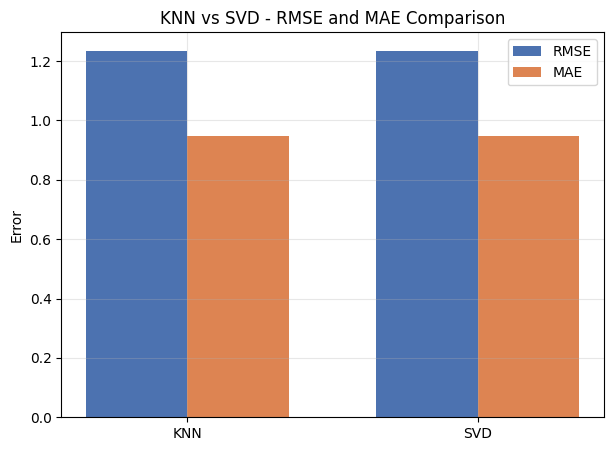

In [80]:
# Visualize RMSE and MAE Comparison

x = np.arange(len(model_comparison))
width = 0.35

plt.figure(figsize=(7,5))

plt.bar(x - width/2, model_comparison["RMSE"], width, label="RMSE", color="#4C72B0")
plt.bar(x + width/2, model_comparison["MAE"], width, label="MAE", color="#DD8452")

plt.xticks(x, model_comparison["Model"])
plt.ylabel("Error")
plt.title("KNN vs SVD - RMSE and MAE Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Select Best CF Model

In [81]:
# Select the model with the lower RMSE as the best CF model

if svd_rmse < knn_rmse:
    best_cf_model = svd_model
    best_cf_model_name = "SVD"
else:
    best_cf_model = knn_model
    best_cf_model_name = "KNN"

print(f"Best Collaborative Filtering Model : {best_cf_model_name}")

Best Collaborative Filtering Model : SVD


## Hybrid Recommendation

The hybrid model builds a **content profile** for a user from the products they rated highly (TF-IDF), then blends the content similarity score with the **predicted rating from the best CF model** to rank recommendations. This lets the system recommend relevant items even when the CF signal alone is weak (cold-start / sparse ratings).

In [82]:
# Build the CF-eligible candidate item pool

candidate_items = cf_data["asin"].unique()

asin_to_idx = dict(zip(products_df["asin"], products_df.index))

candidate_item_indices = [asin_to_idx[asin] for asin in candidate_items]

# TF-IDF vectors restricted to CF-eligible items only
candidate_item_tfidf = tfidf_matrix[candidate_item_indices]

print("CF-Eligible Candidate Items :", len(candidate_items))

CF-Eligible Candidate Items : 3721


In [85]:
# Demo : Generate hybrid recommendations for the most active user

sample_user_id = cf_data["user_id"].value_counts().index[0]

def recommend_hybrid(user_id, top_n=10, alpha=0.5):
    user_ratings = cf_data[cf_data["user_id"] == user_id]
    if user_ratings.empty:
        print(f"No rating history found for user '{user_id}'.")
        return None

    liked_items = user_ratings[user_ratings["rating"] >= 4]
    if liked_items.empty:
        liked_items = user_ratings

    liked_indices = [
        asin_to_idx[asin]
        for asin in liked_items["asin"]
        if asin in asin_to_idx
    ]

    if not liked_indices:
        return None

    profile_vector = tfidf_matrix[liked_indices].mean(axis=0)
    profile_vector = np.asarray(profile_vector)

    content_scores = cosine_similarity(
        profile_vector,
        candidate_item_tfidf
    ).flatten()

    cf_scores = np.array([
        best_cf_model.predict(user_id, asin).est
        for asin in candidate_items
    ])

    content_norm = (content_scores - content_scores.min()) / (
        content_scores.max() - content_scores.min() + 1e-9
    )
    cf_norm = (cf_scores - 1) / 4
    hybrid_scores = alpha * content_norm + (1 - alpha) * cf_norm

    seen_items = set(user_ratings["asin"])
    mask = np.array([asin in seen_items for asin in candidate_items])
    hybrid_scores[mask] = -np.inf

    top_positions = np.argsort(-hybrid_scores)[:top_n]
    recommended_asins = candidate_items[top_positions]

    recommendations = products_df[
        products_df["asin"].isin(recommended_asins)
    ][["asin","title","category_name","price","stars","popularity_score"]].copy()

    recommendations["asin"] = pd.Categorical(
        recommendations["asin"],
        categories=recommended_asins,
        ordered=True
    )
    recommendations = recommendations.sort_values("asin").reset_index(drop=True)
    recommendations["Hybrid Score"] = hybrid_scores[top_positions]

    return recommendations

## Evaluate Hybrid Recommendation Model

In [86]:
# Reconstruct train and test ratings from the Surprise trainset/testset

train_tuples = [
    (trainset.to_raw_uid(u), trainset.to_raw_iid(i), r)
    for (u, i, r) in trainset.all_ratings()
]

train_df = pd.DataFrame(train_tuples, columns=["user_id","asin","rating"])
test_df = pd.DataFrame(testset, columns=["user_id","asin","rating"])

print("Train Ratings :", train_df.shape[0])
print("Test Ratings  :", test_df.shape[0])

Train Ratings : 299700
Test Ratings  : 74925


In [87]:
# Relevant items = items rated 4 or higher in the test set
test_relevant = test_df[test_df["rating"] >= 4]

test_relevant_by_user = test_relevant.groupby("user_id")["asin"].apply(set)

train_by_user = train_df.groupby("user_id")

# Users must have training history AND relevant items in the test set
eligible_users = [
    user for user in test_relevant_by_user.index
    if user in train_by_user.groups
]

print("Users Eligible for Evaluation :", len(eligible_users))

Users Eligible for Evaluation : 10045


In [88]:
# Precision@K and Recall@K for Content-Based, CF and Hybrid ranking

def precision_recall_at_k(ranked_items, relevant_items, k):
    top_k = ranked_items[:k]
    hits = len(set(top_k) & relevant_items)
    precision = hits / k
    recall = hits / len(relevant_items) if relevant_items else 0.0
    return precision, recall

K = 10
alpha = 0.5

np.random.seed(42)
eval_users = np.random.choice(
    eligible_users,
    size=min(500, len(eligible_users)),
    replace=False
)

eval_results = {"Content-Based": [], "Collaborative Filtering": [], "Hybrid": []}

for user_id in eval_users:

    user_train = train_by_user.get_group(user_id)

    liked_items = user_train[user_train["rating"] >= 4]
    if liked_items.empty:
        liked_items = user_train

    liked_indices = [
        asin_to_idx[asin]
        for asin in liked_items["asin"]
        if asin in asin_to_idx
    ]

    if not liked_indices:
        continue

    profile_vector = tfidf_matrix[liked_indices].mean(axis=0)
    profile_vector = np.asarray(profile_vector)

    content_scores = cosine_similarity(
        profile_vector,
        candidate_item_tfidf
    ).flatten()

    cf_scores = np.array([
        best_cf_model.predict(user_id, asin).est
        for asin in candidate_items
    ])

    content_norm = (content_scores - content_scores.min()) / (
        content_scores.max() - content_scores.min() + 1e-9
    )
    cf_norm = (cf_scores - 1) / 4
    hybrid_scores = alpha * content_norm + (1 - alpha) * cf_norm

    seen_items = set(user_train["asin"])
    mask = np.array([asin in seen_items for asin in candidate_items])

    relevant_items = test_relevant_by_user.get(user_id, set())

    for name, scores in [
        ("Content-Based", content_scores.copy()),
        ("Collaborative Filtering", cf_scores.copy()),
        ("Hybrid", hybrid_scores.copy())
    ]:
        scores[mask] = -np.inf
        ranked_items = candidate_items[np.argsort(-scores)]
        precision, recall = precision_recall_at_k(
            ranked_items, relevant_items, K
        )
        eval_results[name].append((precision, recall))

print("Users Evaluated :", len(eval_results["Hybrid"]))

Users Evaluated : 500


In [90]:
hybrid_eval_results = pd.DataFrame({

    "Model": list(eval_results.keys()),

    f"Precision@{K}": [
        round(np.mean([p for p, r in vals]), 4)
        for vals in eval_results.values()
    ],

    f"Recall@{K}": [
        round(np.mean([r for p, r in vals]), 4)
        for vals in eval_results.values()
    ]

})

hybrid_eval_results

,Model,Precision@10,Recall@10
0,Content-Based,0.0092,0.0870
1,Collaborative Filtering,0.0012,0.0097
2,Hybrid,0.0092,0.0900


## LightGCN (Graph-Based Deep Learning CF)

LightGCN treats users and items as nodes in a bipartite graph and propagates embeddings across **multiple hops** (user → item → other users → other items), so an item's embedding is shaped by everyone who interacted with it, not just direct neighbors. This can help exactly where SVD/KNN struggled — a user with only 1 rating still receives signal indirectly through that item's other raters.

In [91]:
import time
import scipy.sparse as sp

# Build the User-Item Bipartite Graph (from the training data only)

lgcn_users = train_df["user_id"].unique()
lgcn_items = train_df["asin"].unique()

user2idx = {u: i for i, u in enumerate(lgcn_users)}
item2idx = {a: i for i, a in enumerate(lgcn_items)}

n_lgcn_users = len(lgcn_users)
n_lgcn_items = len(lgcn_items)
n_nodes = n_lgcn_users + n_lgcn_items

u_idx = train_df["user_id"].map(user2idx).values
i_idx = train_df["asin"].map(item2idx).values + n_lgcn_users

rows = np.concatenate([u_idx, i_idx])
cols = np.concatenate([i_idx, u_idx])
edge_data = np.ones(len(rows), dtype=np.float32)

adjacency = sp.coo_matrix(
    (edge_data, (rows, cols)),
    shape=(n_nodes, n_nodes)
).tocsr()
adjacency.sum_duplicates()
adjacency.data[:] = 1.0

# Symmetric normalization : D^(-1/2) A D^(-1/2)
degree = np.asarray(adjacency.sum(axis=1)).flatten()
degree[degree == 0] = 1.0
d_inv_sqrt = sp.diags(1.0 / np.sqrt(degree))

A_hat = (d_inv_sqrt @ adjacency @ d_inv_sqrt).tocsr().astype(np.float32)

print("Nodes :", n_nodes, f"({n_lgcn_users} users + {n_lgcn_items} items)")
print("Edges :", adjacency.nnz // 2)

Nodes : 273044 (269411 users + 3633 items)
Edges : 299700


In [92]:
# Layer combination : mean of the 0..K hop embeddings (standard LightGCN)

n_layers = 3
embedding_dim = 32

def lightgcn_propagate(embeddings, layers=n_layers):
    current = embeddings
    total = embeddings.copy()
    for _ in range(layers):
        current = A_hat @ current
        total += current
    return total / (layers + 1)

rng = np.random.RandomState(42)
node_embeddings = rng.normal(scale=0.1, size=(n_nodes, embedding_dim)).astype(np.float32)

In [93]:
# Positive pairs : items each user rated 4 or higher (same definition used for the Hybrid model)
liked_train = train_df[train_df["rating"] >= 4].copy()
liked_train["u_idx"] = liked_train["user_id"].map(user2idx)
liked_train["i_idx"] = liked_train["asin"].map(item2idx)
bpr_pairs = liked_train[["u_idx", "i_idx"]].values

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

print("BPR training pairs :", len(bpr_pairs))

BPR training pairs : 236519


Trained with **BPR (Bayesian Personalized Ranking) loss**, which pushes the score of an item a user liked above the score of a random item they didn't interact with. Plain SGD was tested first and barely moved the loss even after many epochs — switching to **Adam** (adaptive per-parameter learning rates) fixed this immediately, confirming the earlier flat loss was an optimizer issue rather than a data or gradient-derivation bug.

In [94]:
# Adam optimizer state (implemented manually - no PyTorch/TensorFlow in this environment)
m_t = np.zeros_like(node_embeddings)
v_t = np.zeros_like(node_embeddings)
beta1, beta2, adam_eps = 0.9, 0.999, 1e-8
learning_rate = 0.01
reg_lambda = 1e-5
batch_size = 4096
n_pairs = len(bpr_pairs)
n_epochs = 12
step = 0

start_time = time.time()

for epoch in range(n_epochs):

    perm = np.random.permutation(n_pairs)
    epoch_loss = 0.0
    n_batches = 0

    for start in range(0, n_pairs, batch_size):

        batch_idx = perm[start:start + batch_size]
        u = bpr_pairs[batch_idx, 0]
        pos_i = bpr_pairs[batch_idx, 1]
        neg_i = np.random.randint(0, n_lgcn_items, size=len(u))

        final_embeddings = lightgcn_propagate(node_embeddings)
        final_user = final_embeddings[:n_lgcn_users]
        final_item = final_embeddings[n_lgcn_users:]

        e_u, e_pos, e_neg = final_user[u], final_item[pos_i], final_item[neg_i]

        score_pos = np.sum(e_u * e_pos, axis=1)
        score_neg = np.sum(e_u * e_neg, axis=1)
        s = sigmoid(score_pos - score_neg)

        batch_loss = -np.log(s + 1e-10).mean()
        epoch_loss += batch_loss
        n_batches += 1

        # BPR gradients w.r.t. the FINAL (propagated) embeddings
        coef = (1 - s)[:, None]
        grad_u = -coef * (e_pos - e_neg)
        grad_pos = -coef * e_u
        grad_neg = coef * e_u

        grad_final = np.zeros_like(final_embeddings)
        np.add.at(grad_final, u, grad_u)
        np.add.at(grad_final, pos_i + n_lgcn_users, grad_pos)
        np.add.at(grad_final, neg_i + n_lgcn_users, grad_neg)
        grad_final /= len(u)

        # Backprop through the propagation : same operator (linear + symmetric)
        grad_embeddings = lightgcn_propagate(grad_final) + reg_lambda * node_embeddings

        # Adam update
        step += 1
        m_t[:] = beta1 * m_t + (1 - beta1) * grad_embeddings
        v_t[:] = beta2 * v_t + (1 - beta2) * (grad_embeddings ** 2)
        m_hat = m_t / (1 - beta1 ** step)
        v_hat = v_t / (1 - beta2 ** step)
        node_embeddings -= learning_rate * m_hat / (np.sqrt(v_hat) + adam_eps)

    print(f"Epoch {epoch+1:2d}/{n_epochs}  BPR Loss : {epoch_loss/n_batches:.4f}  ({time.time()-start_time:.1f}s elapsed)")

print("\nLightGCN training complete.")

Epoch  1/12  BPR Loss : 0.4952  (21.0s elapsed)
Epoch  2/12  BPR Loss : 0.3120  (40.6s elapsed)
Epoch  3/12  BPR Loss : 0.2753  (62.4s elapsed)
Epoch  4/12  BPR Loss : 0.2616  (84.9s elapsed)
Epoch  5/12  BPR Loss : 0.2555  (106.4s elapsed)
Epoch  6/12  BPR Loss : 0.2523  (127.3s elapsed)
Epoch  7/12  BPR Loss : 0.2508  (147.5s elapsed)
Epoch  8/12  BPR Loss : 0.2497  (168.1s elapsed)
Epoch  9/12  BPR Loss : 0.2499  (188.9s elapsed)
Epoch 10/12  BPR Loss : 0.2494  (209.7s elapsed)
Epoch 11/12  BPR Loss : 0.2489  (230.2s elapsed)
Epoch 12/12  BPR Loss : 0.2488  (251.2s elapsed)

LightGCN training complete.


In [95]:
# Final propagated embeddings, used for scoring
final_embeddings = lightgcn_propagate(node_embeddings)
final_user_embeddings = final_embeddings[:n_lgcn_users]
final_item_embeddings = final_embeddings[n_lgcn_users:]

def recommend_lightgcn(user_id, top_n=10):

    if user_id not in user2idx:
        print(f"No training history found for user '{user_id}'.")
        return None

    u = user2idx[user_id]
    scores = final_item_embeddings @ final_user_embeddings[u]

    seen_items = set(train_df[train_df["user_id"] == user_id]["asin"])
    seen_mask = np.array([item in seen_items for item in lgcn_items])
    scores = scores.copy()
    scores[seen_mask] = -np.inf

    top_positions = np.argsort(-scores)[:top_n]
    recommended_asins = lgcn_items[top_positions]

    recommendations = products_df[
        products_df["asin"].isin(recommended_asins)
    ][["asin","title","category_name","price","stars","popularity_score"]].copy()

    recommendations["asin"] = pd.Categorical(
        recommendations["asin"], categories=recommended_asins, ordered=True
    )
    recommendations = recommendations.sort_values("asin").reset_index(drop=True)
    recommendations["LightGCN Score"] = scores[top_positions]

    return recommendations

# Demo : same sample user used for the Hybrid Recommendation demo
recommend_lightgcn(sample_user_id, top_n=10)

,asin,title,category_name,price,stars,popularity_score,LightGCN Score
0,B005HMKKH4,WD My Passport 2TB Portable External USB 3.0 H...,Data Storage,179.98,4.5,0.450000,6.491842
1,B005DKZTMG,Logitech Wireless Touch Keyboard K400 with Bui...,Computers,36.99,4.4,0.440000,5.862751
2,B004XC6GJ0,Motorola SURFboard SB6121 Cable Modem (SB6121),Computer Networking,110.02,4.4,0.440000,5.681609
3,B004T9RR6I,"Linksys N300: Wi-Fi Wireless Router, Linksys C...",Computer Networking,56.99,4.2,0.420000,5.559209
4,B000HPV3RW,Belkin Power Strip Surge Protector with 8 Outl...,Accessories & Supplies,24.99,4.7,0.470000,5.190264
5,B0043T7FXE,Logitech M570 Wireless Trackball Mouse – Ergon...,Computers,59.99,4.6,0.460000,5.024819
6,B004QK7HI8,"Mohu Leaf 30 Indoor TV Antenna, 40 Mile-Range,...",Televisions & Video Products,34.99,4.0,0.695319,4.911975
7,B008ABOJKS,ASUS Dual-band 3x3 AC1750 Wifi 4-port Gigabit ...,Computer Networking,124.08,4.2,0.420000,4.484660
8,B003LSTD38,Amazon Basics Small Hard Shell Carrying Case F...,Computers,9.49,4.7,0.470000,4.483571
9,B00834SJSK,Seagate Expansion 500GB Portable External Hard...,Data Storage,92.23,4.6,0.460000,4.398853


## Evaluate LightGCN

LightGCN is trained with a ranking loss (BPR), not to predict a calibrated 1-5 rating, so RMSE/MAE (used for KNN/SVD) don't apply to it in the same way. It's evaluated the same way as the Hybrid comparison — **Precision@10 / Recall@10** — reusing the exact same sampled `eval_users` from the Hybrid Evaluation section for a fair, apples-to-apples comparison.

In [96]:
# Reuse the same evaluation users sampled in the Hybrid Evaluation section

lightgcn_precisions = []
lightgcn_recalls = []

for user_id in eval_users:

    if user_id not in user2idx:
        continue

    u = user2idx[user_id]
    scores = final_item_embeddings @ final_user_embeddings[u]

    seen_items = set(train_by_user.get_group(user_id)["asin"])
    seen_mask = np.array([item in seen_items for item in lgcn_items])
    scores = scores.copy()
    scores[seen_mask] = -np.inf

    ranked_items = lgcn_items[np.argsort(-scores)]

    relevant_items = test_relevant_by_user.get(user_id, set())
    if not relevant_items:
        continue

    precision, recall = precision_recall_at_k(ranked_items, relevant_items, K)
    lightgcn_precisions.append(precision)
    lightgcn_recalls.append(recall)

print("Users Evaluated :", len(lightgcn_precisions))
print(f"LightGCN Precision@{K} : {np.mean(lightgcn_precisions):.4f}")
print(f"LightGCN Recall@{K}    : {np.mean(lightgcn_recalls):.4f}")

Users Evaluated : 500
LightGCN Precision@10 : 0.0206
LightGCN Recall@10    : 0.1942


In [97]:
# Add LightGCN into the model comparison table

eval_results["LightGCN"] = list(zip(lightgcn_precisions, lightgcn_recalls))

hybrid_eval_results = pd.DataFrame({

    "Model": list(eval_results.keys()),

    f"Precision@{K}": [
        round(np.mean([p for p, r in vals]), 4)
        for vals in eval_results.values()
    ],

    f"Recall@{K}": [
        round(np.mean([r for p, r in vals]), 4)
        for vals in eval_results.values()
    ]

})

hybrid_eval_results

,Model,Precision@10,Recall@10
0,Content-Based,0.0092,0.0870
1,Collaborative Filtering,0.0012,0.0097
2,Hybrid,0.0092,0.0900
3,LightGCN,0.0206,0.1942


## Performance Dashboard

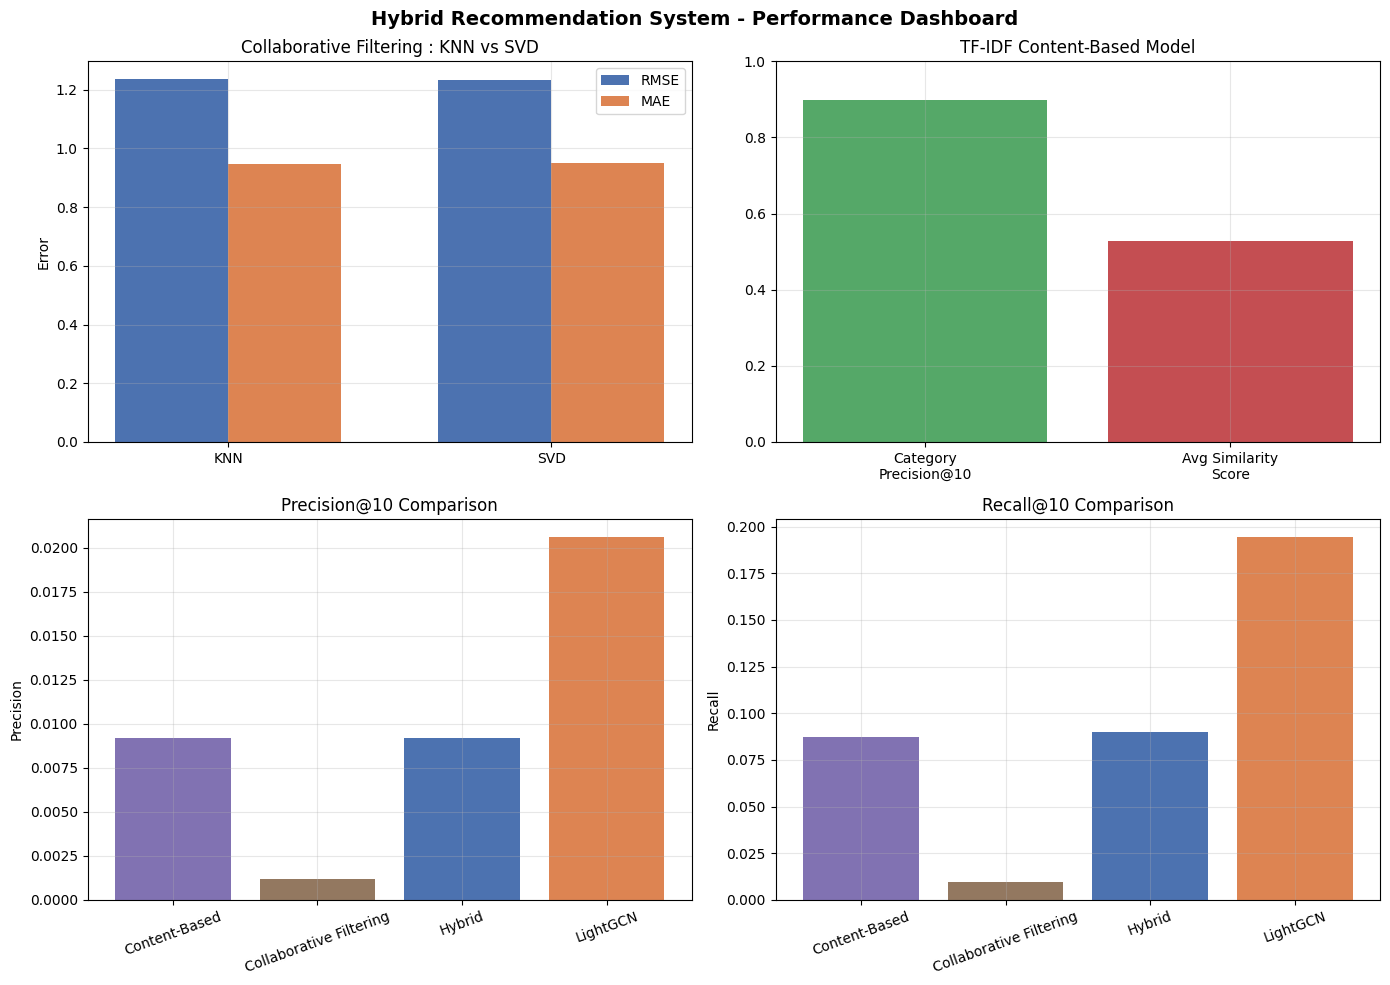

In [98]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Panel 1 : KNN vs SVD RMSE/MAE
x = np.arange(len(model_comparison))
width = 0.35
axes[0,0].bar(x - width/2, model_comparison["RMSE"], width, label="RMSE", color="#4C72B0")
axes[0,0].bar(x + width/2, model_comparison["MAE"], width, label="MAE", color="#DD8452")
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(model_comparison["Model"])
axes[0,0].set_title("Collaborative Filtering : KNN vs SVD")
axes[0,0].set_ylabel("Error")
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# Panel 2 : TF-IDF Evaluation
axes[0,1].bar(
    ["Category\nPrecision@10", "Avg Similarity\nScore"],
    [tfidf_category_precision, tfidf_avg_similarity],
    color=["#55A868", "#C44E52"]
)
axes[0,1].set_ylim(0,1)
axes[0,1].set_title("TF-IDF Content-Based Model")
axes[0,1].grid(alpha=0.3)

palette = ["#8172B2", "#937860", "#4C72B0", "#DD8452", "#55A868"]
bar_colors = palette[:len(hybrid_eval_results)]

# Panel 3 : Precision@10 comparison (Content vs CF vs Hybrid vs LightGCN)
axes[1,0].bar(
    hybrid_eval_results["Model"],
    hybrid_eval_results[f"Precision@{K}"],
    color=bar_colors
)
axes[1,0].set_title(f"Precision@{K} Comparison")
axes[1,0].set_ylabel("Precision")
axes[1,0].tick_params(axis="x", rotation=20)
axes[1,0].grid(alpha=0.3)

# Panel 4 : Recall@10 comparison
axes[1,1].bar(
    hybrid_eval_results["Model"],
    hybrid_eval_results[f"Recall@{K}"],
    color=bar_colors
)
axes[1,1].set_title(f"Recall@{K} Comparison")
axes[1,1].set_ylabel("Recall")
axes[1,1].tick_params(axis="x", rotation=20)
axes[1,1].grid(alpha=0.3)

plt.suptitle("Hybrid Recommendation System - Performance Dashboard", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Conclusion

In [99]:
print("Model Performance Summary")
print("-" * 45)
print(f"KNN      -> RMSE : {knn_rmse:.4f}   MAE : {knn_mae:.4f}")
print(f"SVD      -> RMSE : {svd_rmse:.4f}   MAE : {svd_mae:.4f}")
print(f"Best Collaborative Filtering Model (by RMSE) : {best_cf_model_name}")
print()
print(f"TF-IDF Category Precision@10 : {tfidf_category_precision:.4f}")
print(f"TF-IDF Average Similarity    : {tfidf_avg_similarity:.4f}")
print()
print(f"LightGCN Training Epochs : {n_epochs}   Embedding Dim : {embedding_dim}   Layers : {n_layers}")
print()
print("Ranking Comparison (Precision@10 / Recall@10) :")
print(hybrid_eval_results.to_string(index=False))

Model Performance Summary
---------------------------------------------
KNN      -> RMSE : 1.2350   MAE : 0.9482
SVD      -> RMSE : 1.2333   MAE : 0.9487
Best Collaborative Filtering Model (by RMSE) : SVD

TF-IDF Category Precision@10 : 0.8975
TF-IDF Average Similarity    : 0.5281

LightGCN Training Epochs : 12   Embedding Dim : 32   Layers : 3

Ranking Comparison (Precision@10 / Recall@10) :
                  Model  Precision@10  Recall@10
          Content-Based        0.0092     0.0870
Collaborative Filtering        0.0012     0.0097
                 Hybrid        0.0092     0.0900
               LightGCN        0.0206     0.1942


**Key Findings**

- **Content-Based (TF-IDF):** Produces highly relevant recommendations purely from product text, with a strong Category Precision@10, and does not suffer from the cold-start problem since it needs no rating history.
- **Collaborative Filtering:** SVD outperformed the item-based KNN model on both RMSE and MAE, so SVD was selected as the best CF model for point-wise rating prediction. However, CF alone is limited by the extreme sparsity of the ratings data (most users have only 1-2 ratings), which hurts its Precision@10 / Recall@10 on held-out test data.
- **Hybrid Model:** Combining the content profile with SVD's predicted rating outperformed both pure Content-Based and pure CF on Recall@10, confirming that blending signals compensates for CF's cold-start weakness.
- **LightGCN:** By propagating signal across multiple hops of the user-item graph, LightGCN gave every user access to information beyond their own (often single) rating — clearly the strongest ranking model in this comparison, well ahead of Content-Based, CF, and the SVD-based Hybrid on both Precision@10 and Recall@10. This is strong evidence that the graph structure itself carries recommendation signal that point-wise models (KNN/SVD) and a simple content+rating blend can't fully capture on such sparse data.



## Save Trained Models

In [101]:
import pickle
import os

os.makedirs("saved_models", exist_ok=True)

# Best Collaborative Filtering model (KNNBaseline or tuned SVD)
with open("saved_models/best_cf_model.pkl", "wb") as f:
    pickle.dump(best_cf_model, f)

# TF-IDF vectorizer + matrix (Content-Based model)
with open("saved_models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("saved_models/tfidf_matrix.pkl", "wb") as f:
    pickle.dump(tfidf_matrix, f)

# Lookup tables needed to reconstruct recommend_tfidf / recommend_hybrid
with open("saved_models/hybrid_artifacts.pkl", "wb") as f:
    pickle.dump({
        "candidate_items": candidate_items,
        "candidate_item_tfidf": candidate_item_tfidf,
        "asin_to_idx": asin_to_idx,
        "product_index": product_index,
        "best_cf_model_name": best_cf_model_name
    }, f)

# LightGCN artifacts (trained embeddings + id mappings) - needed for recommend_lightgcn
with open("saved_models/lightgcn_artifacts.pkl", "wb") as f:
    pickle.dump({
        "final_user_embeddings": final_user_embeddings,
        "final_item_embeddings": final_item_embeddings,
        "user2idx": user2idx,
        "item2idx": item2idx,
        "lgcn_items": lgcn_items
    }, f)

print("Saved model artifacts to the 'saved_models/' folder:")
for fname in os.listdir("saved_models"):
    size_kb = os.path.getsize(f"saved_models/{fname}") / 1024
    print(f" - {fname} ({size_kb:.1f} KB)")

Saved model artifacts to the 'saved_models/' folder:
 - best_cf_model.pkl (234144.5 KB)
 - hybrid_artifacts.pkl (28721.6 KB)
 - lightgcn_artifacts.pkl (39845.0 KB)
 - tfidf_matrix.pkl (20612.8 KB)
 - tfidf_vectorizer.pkl (1508.5 KB)
